In [9]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator, interp1d
from collections import namedtuple

In [12]:
def heatinggrids():
    # Grid of velocity and Ye
    YE_GRID = np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5], dtype=np.float64)
    V_GRID = np.array([0.05, 0.1, 0.2, 0.3, 0.4, 0.5], dtype=np.float64)

    # Approximant coefficients on the grid
    E0_GRID = np.array([
        1.000, 1.000, 1.000, 1.000, 1.000, 1.000,
        1.000, 1.000, 1.041, 1.041, 1.041, 1.041,
        1.146, 1.000, 1.041, 1.041, 1.041, 1.041,
        1.146, 1.000, 1.000, 1.000, 1.041, 1.041,
        1.301, 1.398, 1.602, 1.580, 1.763, 1.845,
        0.785, 1.255, 1.673, 1.673, 1.874, 1.874,
        0.863, 0.845, 1.212, 1.365, 1.635, 2.176,
        -2.495, -2.495, -2.097, -2.155, -2.046, -1.824,
        -0.699, -0.699, -0.222, 0.176, 0.176, 0.176,
        -0.398, 0.000, 0.301, 0.477, 0.477, 0.477], dtype=np.float64)

    # Reshape GRIDs to a 2D array
    E0_GRID = E0_GRID.reshape((len(V_GRID), len(YE_GRID)), order='F')

    # ALP_GRID
    ALP_GRID = np.array([
        1.37, 1.38, 1.41, 1.41, 1.41, 1.41,
        1.41, 1.38, 1.37, 1.37, 1.37, 1.37,
        1.41, 1.38, 1.37, 1.37, 1.37, 1.37,
        1.36, 1.25, 1.32, 1.32, 1.34, 1.34,
        1.44, 1.40, 1.46, 1.66, 1.60, 1.60,
        1.36, 1.33, 1.33, 1.33, 1.374, 1.374,
        1.40, 1.358, 1.384, 1.384, 1.384, 1.344,
        1.80, 1.80, 2.10, 2.10, 1.90, 1.90,
        8.00, 8.00, 7.00, 7.00, 7.00, 7.00,
        1.40, 1.40, 1.40, 1.60, 1.60, 1.60
    ], dtype=np.float64)

    ALP_GRID = ALP_GRID.reshape((len(V_GRID), len(YE_GRID)), order='F')

    # T0_GRID
    T0_GRID = np.array([
        1.80, 1.40, 1.20, 1.20, 1.20, 1.20,
        1.40, 1.00, 0.85, 0.85, 0.85, 0.85,
        1.00, 0.80, 0.65, 0.65, 0.61, 0.61,
        0.85, 0.60, 0.45, 0.45, 0.45, 0.45,
        0.65, 0.38, 0.22, 0.18, 0.12, 0.095,
        0.540, 0.31, 0.18, 0.13, 0.095, 0.081,
        0.385, 0.235, 0.1, 0.06, 0.035, 0.025,
        26.0, 26.0, 0.4, 0.4, 0.12, -20.0,
        0.20, 0.12, 0.05, 0.03, 0.025, 0.021,
        0.16, 0.08, 0.04, 0.02, 0.018, 0.016
    ], dtype=np.float64)

    T0_GRID = T0_GRID.reshape((len(V_GRID), len(YE_GRID)), order='F')

    # SIG_GRID
    SIG_GRID = np.array([
        0.08, 0.08, 0.095, 0.095, 0.095, 0.095,
        0.10, 0.08, 0.070, 0.070, 0.070, 0.070,
        0.07, 0.08, 0.070, 0.065, 0.070, 0.070,
        0.040, 0.030, 0.05, 0.05, 0.05, 0.050,
        0.05, 0.030, 0.025, 0.045, 0.05, 0.05,
        0.11, 0.04, 0.021, 0.021, 0.017, 0.017,
        0.10, 0.094, 0.068, 0.05, 0.03, 0.01,
        45.0, 45.0, 45.0, 45.0, 25.0, 40.0,
        0.20, 0.12, 0.05, 0.03, 0.025, 0.021,
        0.03, 0.015, 0.007, 0.01, 0.009, 0.007
    ], dtype=np.float64)

    SIG_GRID = SIG_GRID.reshape((len(V_GRID), len(YE_GRID)), order='F')

    # ALP1_GRID
    ALP1_GRID = np.array([
        7.50, 7.50, 7.50, 7.50, 7.50, 7.50,
        9.00, 9.00, 7.50, 7.50, 7.00, 7.00,
        8.00, 8.00, 7.50, 7.50, 7.00, 7.00,
        8.00, 8.00, 7.50, 7.50, 7.00, 7.00,
        8.00, 8.00, 5.00, 7.50, 7.00, 6.50,
        4.5, 3.8, 4.0, 4.0, 4.0, 4.0,
        2.4, 3.8, 3.8, 3.21, 2.91, 3.61,
        -1.55, -1.55, -0.75, -0.75, -2.50, -5.00,
        -1.55, -1.55, -1.55, -1.55, -1.55, -1.55,
        3.00, 3.00, 3.00, 3.00, 3.00, 3.00
    ], dtype=np.float64)

    ALP1_GRID = ALP1_GRID.reshape((len(V_GRID), len(YE_GRID)), order='F')

    # T1_GRID
    T1_GRID = np.array([
        0.040, 0.025, 0.014, 0.010, 0.008, 0.006,
        0.040, 0.035, 0.020, 0.012, 0.010, 0.008,
        0.080, 0.040, 0.020, 0.012, 0.012, 0.009,
        0.080, 0.040, 0.030, 0.018, 0.012, 0.009,
        0.080, 0.060, 0.065, 0.028, 0.020, 0.015,
        0.14, 0.123, 0.089, 0.060, 0.045, 0.031,
        0.264, 0.1, 0.07, 0.055, 0.042, 0.033,
        1.0, 1.0, 1.0, 1.0, 0.02, 0.01,
        1.0, 1.0, 1.0, 1.0, 1.0, 1.0,
        0.04, 0.02, 0.01, 0.002, 0.002, 0.002
    ], dtype=np.float64)

    T1_GRID = T1_GRID.reshape((len(V_GRID), len(YE_GRID)), order='F')

    SIG1_GRID = np.array([0.250, 0.120, 0.045, 0.028, 0.020, 0.015,
                          0.250, 0.060, 0.035, 0.020, 0.016, 0.012,
                          0.170, 0.090, 0.035, 0.020, 0.012, 0.009,
                          0.170, 0.070, 0.035, 0.015, 0.012, 0.009,
                          0.170, 0.070, 0.050, 0.025, 0.020, 0.020,
                          0.065, 0.067, 0.053, 0.032, 0.032, 0.024,
                          0.075, 0.044, 0.03, 0.02, 0.02, 0.014,
                          10.0, 10.0, 10.0, 10.0, 0.02, 0.01,
                          10.0, 10.0, 10.0, 10.0, 10.0, 10.0,
                          0.01, 0.005, 0.002, 1e-4, 1e-4, 1e-4])

    SIG1_GRID = SIG1_GRID.reshape((len(V_GRID), len(YE_GRID)), order='F')

    C1_GRID = np.array([27.2, 27.8, 28.2, 28.2, 28.2, 28.2,
                        28.0, 27.8, 27.8, 27.8, 27.8, 27.8,
                        27.5, 27.0, 27.8, 27.8, 27.8, 27.8,
                        28.8, 28.1, 27.8, 27.8, 27.5, 27.5,
                        28.5, 28.0, 27.5, 28.5, 29.2, 29.0,
                        25.0, 27.5, 25.8, 20.9, 29.3, 1.0,
                        28.7, 27.0, 28.0, 28.0, 27.4, 25.3,
                        28.5, 29.1, 29.5, 30.1, 30.4, 29.9,
                        20.4, 20.6, 20.8, 20.9, 20.9, 21.0,
                        29.9, 30.1, 30.1, 30.2, 30.3, 30.3])

    C1_GRID = C1_GRID.reshape((len(V_GRID), len(YE_GRID)), order='F')

    TAU1_GRID = np.array([4.07, 4.07, 4.07, 4.07, 4.07, 4.07,
                          4.07, 4.07, 4.07, 4.07, 4.07, 4.07,
                          4.07, 4.07, 4.07, 4.07, 4.07, 4.07,
                          4.07, 4.07, 4.07, 4.07, 4.07, 4.07,
                          4.77, 4.77, 4.77, 4.77, 4.07, 4.07,
                          4.77, 4.77, 28.2, 1.03, 0.613, 1.0,
                          3.4, 14.5, 11.4, 14.3, 13.3, 13.3,
                          2.52, 2.52, 2.52, 2.52, 2.52, 2.52,
                          1.02, 1.02, 1.02, 1.02, 1.02, 1.02,
                          0.22, 0.22, 0.22, 0.22, 0.22, 0.22])

    TAU1_GRID = TAU1_GRID.reshape((len(V_GRID), len(YE_GRID)), order='F')

    C2_GRID = np.array([21.5, 21.5, 22.1, 22.1, 22.1, 22.1,
                        22.3, 21.5, 21.5, 21.8, 21.8, 21.8,
                        22.0, 21.5, 21.5, 22.0, 21.8, 21.8,
                        23.5, 22.5, 22.1, 22.0, 22.2, 22.2,
                        22.0, 22.8, 23.0, 23.0, 23.5, 23.5,
                        10.0, 0.0, 0.0, 19.8, 22.0, 21.0,
                        26.2, 14.1, 18.8, 19.1, 23.8, 19.2,
                        25.4, 25.4, 25.8, 26.0, 26.0, 25.8,
                        18.4, 18.4, 18.6, 18.6, 18.6, 18.6,
                        27.8, 28.0, 28.2, 28.2, 28.3, 28.3])

    C2_GRID = C2_GRID.reshape((len(V_GRID), len(YE_GRID)), order='F')

    TAU2_GRID = np.array([4.62, 4.62, 4.62, 4.62, 4.62, 4.62,
                          4.62, 4.62, 4.62, 4.62, 4.62, 4.62,
                          4.62, 4.62, 4.62, 4.62, 4.62, 4.62,
                          4.62, 4.62, 4.62, 4.62, 4.62, 4.62,
                          5.62, 5.62, 5.62, 5.62, 4.62, 4.62,
                          5.62, 5.18, 5.18, 34.7, 8.38, 22.6,
                          0.15, 4.49, 95.0, 95.0, 0.95, 146.,
                          0.12, 0.12, 0.12, 0.12, 0.12, 0.14,
                          0.32, 0.32, 0.32, 0.32, 0.32, 0.32,
                          0.02, 0.02, 0.02, 0.02, 0.02, 0.02])

    TAU2_GRID = TAU2_GRID.reshape((len(V_GRID), len(YE_GRID)), order='F')

    C3_GRID = np.array([19.4, 19.8, 20.1, 20.1, 20.1, 20.1,
                        20.0, 19.8, 19.8, 19.8, 19.8, 19.8,
                        19.9, 19.8, 19.8, 19.8, 19.8, 19.8,
                        5.9, 9.8, 23.5, 23.5, 23.5, 23.5,
                        27.3, 26.9, 26.6, 27.4, 25.8, 25.8,
                        27.8, 26.9, 18.9, 25.4, 24.8, 25.8,
                        22.8, 17.9, 18.9, 25.4, 24.8, 25.5,
                        20.6, 20.2, 19.8, 19.2, 19.5, 18.4,
                        12.6, 13.1, 14.1, 14.5, 14.5, 14.5,
                        24.3, 24.2, 24.0, 24.0, 24.0, 23.9])

    C3_GRID = C3_GRID.reshape((len(V_GRID), len(YE_GRID)), order='F')

    TAU3_GRID = np.array([18.2, 18.2, 18.2, 18.2, 18.2, 18.2,
                          18.2, 18.2, 18.2, 18.2, 18.2, 18.2,
                          18.2, 18.2, 18.2, 18.2, 18.2, 18.2,
                          18.2, 18.2, 0.62, 0.62, 0.62, 0.62,
                          0.18, 0.18, 0.18, 0.18, 0.32, 0.32,
                          0.12, 0.18, 50.8, 0.18, 0.32, 0.32,
                          2.4, 51.8, 50.8, 0.18, 0.32, 0.32,
                          3.0, 2.5, 2.4, 2.4, 2.4, 60.4,
                          200., 200., 200., 200., 200., 200.,
                          8.76, 8.76, 8.76, 8.76, 8.76, 8.76])

    TAU3_GRID = TAU3_GRID.reshape((len(V_GRID), len(YE_GRID)), order='F')

    # make interpolants
    E0_interp = RegularGridInterpolator((V_GRID, YE_GRID), E0_GRID, bounds_error=False, fill_value=None)
    ALP_interp = RegularGridInterpolator((V_GRID, YE_GRID), ALP_GRID, bounds_error=False, fill_value=None)
    T0_interp = RegularGridInterpolator((V_GRID, YE_GRID), T0_GRID, bounds_error=False, fill_value=None)
    SIG_interp = RegularGridInterpolator((V_GRID, YE_GRID), SIG_GRID, bounds_error=False, fill_value=None)
    ALP1_interp = RegularGridInterpolator((V_GRID, YE_GRID), ALP1_GRID, bounds_error=False, fill_value=None)
    T1_interp = RegularGridInterpolator((V_GRID, YE_GRID), T1_GRID, bounds_error=False, fill_value=None)
    SIG1_interp = RegularGridInterpolator((V_GRID, YE_GRID), SIG1_GRID, bounds_error=False, fill_value=None)
    C1_interp = RegularGridInterpolator((V_GRID, YE_GRID), C1_GRID, bounds_error=False, fill_value=None)
    TAU1_interp = RegularGridInterpolator((V_GRID, YE_GRID), TAU1_GRID, bounds_error=False, fill_value=None)
    C2_interp = RegularGridInterpolator((V_GRID, YE_GRID), C2_GRID, bounds_error=False, fill_value=None)
    TAU2_interp = RegularGridInterpolator((V_GRID, YE_GRID), TAU2_GRID, bounds_error=False, fill_value=None)
    C3_interp = RegularGridInterpolator((V_GRID, YE_GRID), C3_GRID, bounds_error=False, fill_value=None)
    TAU3_interp = RegularGridInterpolator((V_GRID, YE_GRID), TAU3_GRID, bounds_error=False, fill_value=None)

    interpolators = namedtuple('interpolators', ['E0', 'ALP', 'T0', 'SIG', 'ALP1', 'T1', 'SIG1',
                                                 'C1', 'TAU1', 'C2', 'TAU2', 'C3', 'TAU3'])
    interpolators.E0 = E0_interp
    interpolators.ALP = ALP_interp
    interpolators.T0 = T0_interp
    interpolators.SIG = SIG_interp
    interpolators.ALP1 = ALP1_interp
    interpolators.T1 = T1_interp
    interpolators.SIG1 = SIG1_interp
    interpolators.C1 = C1_interp
    interpolators.TAU1 = TAU1_interp
    interpolators.C2 = C2_interp
    interpolators.TAU2 = TAU2_interp
    interpolators.C3 = C3_interp
    interpolators.TAU3 = TAU3_interp
    return interpolators


def get_heating_terms(ye, vel, **kwargs):
    ints = heatinggrids()
    e0 = ints.E0([vel, ye])[0]
    alp = ints.ALP([vel, ye])[0]
    t0 = ints.T0([vel, ye])[0]
    sig = ints.SIG([vel, ye])[0]
    alp1 = ints.ALP1([vel, ye])[0]
    t1 = ints.T1([vel, ye])[0]
    sig1 = ints.SIG1([vel, ye])[0]
    c1 = ints.C1([vel, ye])[0]
    tau1 = ints.TAU1([vel, ye])[0]
    c2 = ints.C2([vel, ye])[0]
    tau2 = ints.TAU2([vel, ye])[0]
    c3 = ints.C3([vel, ye])[0]
    tau3 = ints.TAU3([vel, ye])[0]
    heating_terms = namedtuple('heating_terms', ['e0', 'alp', 't0', 'sig', 'alp1', 't1', 'sig1', 'c1',
                                                 'tau1', 'c2', 'tau2', 'c3', 'tau3'])

    heating_rate_fudge = kwargs.get('heating_rate_fudge', 1.0)
    heating_terms.e0 = e0 * heating_rate_fudge
    heating_terms.alp = alp * heating_rate_fudge
    heating_terms.t0 = t0 * heating_rate_fudge
    heating_terms.sig = sig * heating_rate_fudge
    heating_terms.alp1 = alp1 * heating_rate_fudge
    heating_terms.t1 = t1 * heating_rate_fudge
    heating_terms.sig1 = sig1 * heating_rate_fudge
    heating_terms.c1 = c1 * heating_rate_fudge
    heating_terms.tau1 = tau1 * heating_rate_fudge
    heating_terms.c2 = c2 * heating_rate_fudge
    heating_terms.tau2 = tau2 * heating_rate_fudge
    heating_terms.c3 = c3 * heating_rate_fudge
    heating_terms.tau3 = tau3 * heating_rate_fudge

    print(heating_terms)
    return heating_terms

In [16]:
m= get_heating_terms(ye=0.25, vel=0.5)

<class '__main__.heating_terms'>


In [18]:
m = get_heating_terms(ye=0.25, vel=0.5)

for name in [
    "e0", "alp", "t0", "sig", "alp1", "t1", "sig1",
    "c1", "tau1", "c2", "tau2", "c3", "tau3"
]:
    print(f"{name:6s} = {getattr(m, name)}")

<class '__main__.heating_terms'>
e0     = 1.845
alp    = 1.6
t0     = 0.095
sig    = 0.05
alp1   = 6.5
t1     = 0.015
sig1   = 0.02
c1     = 29.0
tau1   = 4.07
c2     = 23.5
tau2   = 4.62
c3     = 25.8
tau3   = 0.32


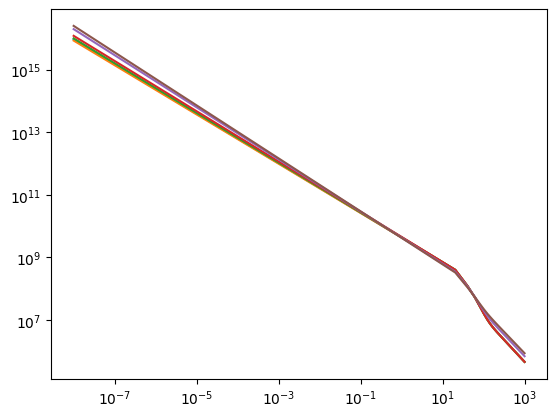

In [26]:
t=jnp.linspace(1.0e-8, 1.0e3)
Ye=0.05
for k in [0.5,0.4,0.3,0.2,0.1,0.05]:
    
    heating = heating_rate(t*86400, Ye=0.05, v_ej=k)

    plt.plot(t,heating)

plt.xscale("log")
plt.yscale("log")

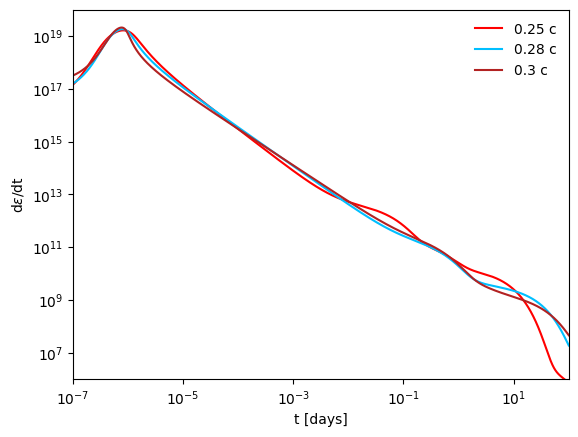

In [38]:
Ye_list = [0.25,0.28,0.30]
v_list = [0.1, 0.15, 0.2]
colors = ["red", "deepskyblue", "firebrick", "purple", "blue", "deepskyblue"]

t = jnp.geomspace(1e-7, 1e2, 2000)
for v, c in zip(Ye_list, colors):
    heating = heating_rate(t * 86400, Ye=v, v_ej=0.5)
    label = f"Ye = {Ye}, v = {v} Ye" if v == v_list[0] else f"{v} c"
    plt.plot(t, heating, color=c, label=label)

plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-7, 1e2)
plt.ylim(1e6, 1e20)
plt.xlabel("t [days]")
plt.ylabel(r"d$\varepsilon$/dt")
plt.legend(loc="upper right", frameon=False)